In [1]:
#mounting gogle drive
#from google.colab import drive
#drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [1]:
#!pip install keras
#!pip install tensorflow
#!pip install matplotlib

  Using cached Keras-2.4.3-py2.py3-none-any.whl (36 kB)


In [3]:
#!python -m pip uninstall tensorflow --yes

Found existing installation: tensorflow 2.4.1
Uninstalling tensorflow-2.4.1:
  Successfully uninstalled tensorflow-2.4.1


In [2]:
#!pip install tensorflow-gpu

  Using cached tensorflow_gpu-2.4.1-cp38-cp38-win_amd64.whl (370.7 MB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
  Using cached absl_py-0.12.0-py3-none-any.whl (129 kB)
  Using cached tensorboard-2.4.1-py3-none-any.whl (10.6 MB)
  Using cached flatbuffers-1.12-py2.py3-none-any.whl (15 kB)
  Using cached termcolor-1.1.0-py3-none-any.whl
  Using cached grpcio-1.32.0-cp38-cp38-win_amd64.whl (2.6 MB)
  Using cached wrapt-1.12.1-py3-none-any.whl
  Using cached Keras_Preprocessing-1.1.2-py2.py3-none-any.whl (42 kB)
  Using cached tensorflow_estimator-2.4.0-py2.py3-none-any.whl (462 kB)
  Using cached opt_einsum-3.3.0-py3-none-any.whl (65 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
  Using cached gast-0.3.3-py2.py3-none-any.whl (9.7 kB)
  Using cached protobuf-3.15.7-py2.py3-none-any.whl (173 kB)
  Using cached Markdown-3.3.4-py3-none-any.whl (97 kB)
  Using cached google_auth_oauthlib-0.4.4-py2.py3-none-any.whl (18 kB)
  Using cached google_auth-1.28.0-p

In [1]:
#from tensorflow.python.client import device_lib 
#print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 13733069732014297229
]


In [4]:
#import tensorflow as tf
#from tensorflow.compat.v1 import Session

In [5]:
#sess = tf.Session(config=tf.ConfigProto(log_device_placement=True))

AttributeError: module 'tensorflow' has no attribute 'Session'

In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
print(tf.test.is_built_with_cuda())

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
True


In [2]:
tf.python.client.device_lib.list_local_devices()

AttributeError: module 'tensorflow' has no attribute 'python'

In [1]:
#from tensorflow.compat.v1 import ConfigProto
#from tensorflow.compat.v1 import InteractiveSession
#config = ConfigProto()
#config.gpu_options.per_process_gpu_memory_fraction = 0.8
#config.gpu_options.allow_growth = True
#session = InteractiveSession(config = config)

In [40]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
#from tensorflow.keras.applications.inception_v3 import InceptionV3              #M-1
#from tensorflow.keras.applications.vgg16 import VGG16                             #M-2
#from tensorflow.keras.applications.vgg19 import VGG19                              #M-5
#from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2                #M-3
from tensorflow.keras.applications.resnet50 import ResNet50                       #m-4
#from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input  
#from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
#from tensorflow.keras.applications.vgg19 import preprocess_input
#from tensorflow.keras.applications.vgg16 import preprocess_input           
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adadelta, Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

In [41]:
#resize all the images to this:

IMAGE_SIZE =[75, 100]
train_path = 'base_dir/base_dir/train_dir'
valid_path = 'base_dir/base_dir/val_dir'

In [46]:
resnet = ResNet50(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False, pooling='avg')

94773248/94765736 [==============================] - 12s 0us/step


In [47]:
#inceptionv3 = InceptionV3(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [48]:
#vgg= VGG19(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [49]:
resnet.summary()

Model: "resnet50"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, 75, 100, 3)] 0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 81, 106, 3)   0           input_3[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 38, 50, 64)   9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
conv1_bn (BatchNormalization)   (None, 38, 50, 64)   256         conv1_conv[0][0]                 
___________________________________________________________________________________________

In [50]:
folders = glob('base_dir/base_dir/train_dir/*')
folders

['base_dir/base_dir/train_dir\\akiec',
 'base_dir/base_dir/train_dir\\bcc',
 'base_dir/base_dir/train_dir\\bkl',
 'base_dir/base_dir/train_dir\\df',
 'base_dir/base_dir/train_dir\\mel',
 'base_dir/base_dir/train_dir\\nv',
 'base_dir/base_dir/train_dir\\vasc']

In [51]:
#for layer in vgg.layers:
  #layer.trainable = False
for layer in resnet.layers:
   layer.trainable = False
for layer in resnet.layers[-22:]:
    layer.trainable = True

In [57]:
#flattening the layer
from tensorflow.keras.regularizers import l2
import tensorflow as tf
#x = Dropout(rate = 0.5)(x)
#x = Dense(units = 128, kernel_regularizer=tf.keras.regularizers.l2(0.001), activation = 'relu')(x)
#x = Dropout(rate = 0.5)(x)
#x = Dropout(rate = 0.5)(x) 
#x = GlobalAveragePooling2D()(x)
#x = Dense(units = 128, activation = 'relu')(x)
#x = Dropout(rate = 0.4)(x) 
#x = Dense(len(folders), kernel_regularizer=tf.keras.regularizers.l2(0.01),  activation='linear')(x)
#x = BatchNormalization()(x)
#x = Dropout(rate = 0.2)(x)
#x = Flatten()(inceptionv3.output)
x = Dropout(rate = 0.5)(resnet.output)
x = Dense(128, activation="relu",kernel_regularizer=tf.keras.regularizers.l2(0.02))(x)
x = Dropout(rate = 0.5)(x)
#x = Dense(num_labels, activation = 'softmax',kernel_regularizer=regularizers.l2(0.02)(x)
#x = Dense(units = 128, activation = 'relu')(x)
#x = Dropout(rate = 0.2)(x)

In [60]:
from tensorflow.keras.regularizers import l2
import tensorflow as tf
prediction = Dense(len(folders),  kernel_regularizer=tf.keras.regularizers.l2(0.02), activation='softmax')(x)

In [61]:
#create a model object
model = Model(inputs = resnet.input, outputs = prediction)

In [62]:
#model summary
model.summary()

Model: "model_4"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, 75, 100, 3)] 0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 81, 106, 3)   0           input_3[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 38, 50, 64)   9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
conv1_bn (BatchNormalization)   (None, 38, 50, 64)   256         conv1_conv[0][0]                 
____________________________________________________________________________________________

In [63]:
#model compilation
model.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [67]:
import keras
from keras.callbacks import Callback
class SnapshotEnsemble(Callback):
    
    __snapshot_name_fmt = "snapshot_%d.hdf5"
    
    def __init__(self, n_models, n_epochs_per_model, lr_max, verbose=1):
        """
        n_models -- quantity of models (snapshots)
        n_epochs_per_model -- quantity of epoch for every model (snapshot)
        lr_max -- maximum learning rate (snapshot starter)
        """
        self.n_epochs_per_model = n_epochs_per_model
        self.n_models = n_models
        self.n_epochs_total = self.n_models * self.n_epochs_per_model
        self.lr_max = lr_max
        self.verbose = verbose
        self.lrs = []
 
    # calculate learning rate for epoch
    def cosine_annealing(self, epoch):
        cos_inner = (math.pi * (epoch % self.n_epochs_per_model)) / self.n_epochs_per_model
        return self.lr_max / 2 * (math.cos(cos_inner) + 1)

    # when epoch begins update learning rate
    def on_epoch_begin(self, epoch, logs={}):
        # update learning rate
        lr = self.cosine_annealing(epoch)
        backend.set_value(self.model.optimizer.lr, lr)
        # log value
        self.lrs.append(lr)

    # when epoch ends check if there is a need to save a snapshot
    def on_epoch_end(self, epoch, logs={}):
        if (epoch + 1) % self.n_epochs_per_model == 0:
            # save model to file
            filename = self.__snapshot_name_fmt % ((epoch + 1) // self.n_epochs_per_model)
            self.model.save(filename)
            if self.verbose:
                print('Epoch %d: snapshot saved to %s' % (epoch, filename))
                
    # load all snapshots after training
    def load_ensemble(self):
        models = []
        for i in range(self.n_models):
            models.append(load_model(self.__snapshot_name_fmt % (i + 1)))
        return models

Using TensorFlow backend.


In [74]:
reduce_lr = ReduceLROnPlateau(
    monitor= 'val_accuracy', factor=0.5,patience=3, verbose=1, min_lr=0.00001)

In [75]:
#use Image data generator to import the images from the dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen =ImageDataGenerator(rescale = 1./255,
                                 featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.1, # Randomly zoom image 
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=False,  # randomly flip images
        vertical_flip=False)
test_datagen =ImageDataGenerator(rescale = 1./255)

In [76]:
training_set = train_datagen.flow_from_directory('base_dir/base_dir/train_dir',
                                                 target_size = (75, 100),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 38569 images belonging to 7 classes.


In [77]:
test_set = test_datagen.flow_from_directory('base_dir/base_dir/val_dir',
                                                 target_size = (75, 100),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 938 images belonging to 7 classes.


In [78]:
#fit the model
import math
from keras import backend
se_callback = SnapshotEnsemble(n_models=3, n_epochs_per_model=10
, lr_max=.001)
r = model.fit(
    training_set,
    validation_data = test_set,
    epochs = 30,
    steps_per_epoch = len(training_set),
    validation_steps = len(test_set),
    callbacks = [se_callback], verbose=1
)

  ...
    to  
  ['...']
  ...
    to  
  ['...']
Train for 1206 steps, validate for 30 steps
Epoch 1/30
1206/1206 [==============================] - 108s 89ms/step - loss: 1.9412 - accuracy: 0.1527 - val_loss: nan - val_accuracy: 0.0512
Epoch 2/30
 751/1206 [=================>............] - ETA: 38s - loss: 1.9413 - accuracy: 0.1502

KeyboardInterrupt: 

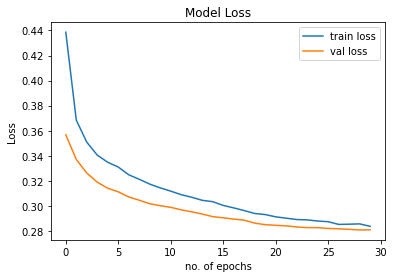

In [44]:
plt.plot(r.history['loss'], label = 'train loss')
plt.plot(r.history['val_loss'], label = 'val loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('no. of epochs')
plt.legend()
plt.show()

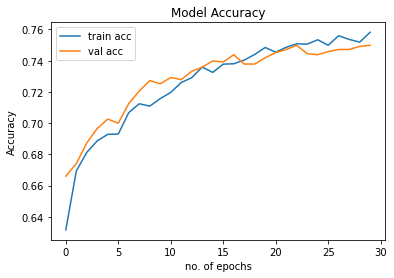

In [45]:
plt.plot(r.history['accuracy'], label = 'train acc')
plt.plot(r.history['val_accuracy'], label = 'val acc')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('no. of epochs')
plt.legend()
plt.show()

In [46]:
from tensorflow.keras.models import load_model
model.save ('model_vgg.h5')

In [47]:
y_pred = model.predict(test_set)

In [48]:
print(y_pred)

[[-2.585783   -2.0145257  -1.3871238  ... -1.4487325   0.7594835
  -2.0036125 ]
 [-2.5519655  -3.3384686  -0.7736138  ... -1.631006    0.0381269
  -2.2700794 ]
 [-2.6069527  -3.1679282   0.25751674 ... -2.3517375  -0.7745635
  -2.3731883 ]
 ...
 [-1.4915351  -1.6607891  -0.94176906 ... -1.6411796  -0.73629373
  -1.2451416 ]
 [-2.8688784  -3.3743973  -2.5748346  ... -2.6188378   2.2456515
  -2.4298897 ]
 [-2.271739   -2.9309616  -1.6777639  ... -1.4806993   2.0803726
  -2.3513381 ]]


In [49]:
import numpy as np
y_pred = np.argmax(y_pred, axis=1)
print(y_pred)

[5 5 2 ... 5 5 5]


In [51]:
#confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
print('Confusion Matrix')
#dict_characters = {0: "akiec", 1: "bcc", 2: "bkl", 3: "df", 4: "mel", 5: "nv", 6: "vasc"}
confusion_matrix= confusion_matrix(test_set.classes, y_pred)
#confusion_matrix(confusion_matrix, classes = list(dict_characters.values()))
print(confusion_matrix)
#import seaborn as sns
#sns.heatmap(confusion_matrix, annot=True)
print('\nClassification Report')
target_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
print(classification_report(test_set.classes, y_pred, target_names=target_names))

Confusion Matrix
[[  0   1   7   0   2  39   0]
 [  2   2   7   0   3  63   0]
 [  4   5  14   0  13 129   0]
 [  0   1   2   0   0  14   0]
 [  2   6  18   0   9 131   1]
 [ 13  26 134   0  52 779   2]
 [  0   0   2   0   1  19   0]]

Classification Report
              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        49
         bcc       0.05      0.03      0.03        77
         bkl       0.08      0.08      0.08       165
          df       0.00      0.00      0.00        17
         mel       0.11      0.05      0.07       167
          nv       0.66      0.77      0.71      1006
        vasc       0.00      0.00      0.00        22

    accuracy                           0.53      1503
   macro avg       0.13      0.13      0.13      1503
weighted avg       0.47      0.53      0.50      1503

